In [1]:
# Dataset Structuring and Validation (Week 2–3)

# This notebook performs exploratory data analysis (EDA) and 
# validation on the residential MLS datasets.

# --------- Steps include: -----------
# Dataset understanding
# Missing value analysis
# Numeric distribution review
# Mortgage rate enrichment (FRED API)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [10]:
# Load datasets
sold = pd.read_csv("../output/sold_combined_residential.csv", nrows=1000)
listings = pd.read_csv("../output/listings_combined_residential.csv", nrows=1000)

print("Sold shape:", sold.shape)
print("Listings shape:", listings.shape)

Sold shape: (1000, 84)
Listings shape: (1000, 84)


In [11]:
sold.head()
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 84 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 999 non-null    str    
 1   ListAgentAOR                  999 non-null    str    
 2   Flooring                      605 non-null    str    
 3   ViewYN                        892 non-null    object 
 4   WaterfrontYN                  2 non-null      object 
 5   BasementYN                    9 non-null      object 
 6   PoolPrivateYN                 891 non-null    object 
 7   OriginalListPrice             979 non-null    float64
 8   ListingKey                    1000 non-null   int64  
 9   ListAgentEmail                999 non-null    str    
 10  CloseDate                     1000 non-null   str    
 11  ClosePrice                    1000 non-null   float64
 12  ListAgentFirstName            987 non-null    str    
 13  ListAgentLastNa

In [12]:
# Property Type Check
sold['PropertyType'].value_counts()

PropertyType
Residential    1000
Name: count, dtype: int64

In [13]:
# Missing Values Analysis
missing = sold.isnull().sum()
missing_pct = (missing / len(sold)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

missing_df.head(20)


,Missing Count,Missing %
lonfilled,1000,100.0
BuyerAgencyCompensation,1000,100.0
FireplacesTotal,1000,100.0
AboveGradeFinishedArea,1000,100.0
TaxAnnualAmount,1000,100.0
CoveredSpaces,1000,100.0
MiddleOrJuniorSchoolDistrict,1000,100.0
BuyerAgencyCompensationType,1000,100.0
latfilled,1000,100.0
BusinessType,1000,100.0


In [14]:
# Flag high missing
high_missing = missing_df[missing_df['Missing %'] > 90]
high_missing

,Missing Count,Missing %
lonfilled,1000,100.0
BuyerAgencyCompensation,1000,100.0
FireplacesTotal,1000,100.0
AboveGradeFinishedArea,1000,100.0
TaxAnnualAmount,1000,100.0
CoveredSpaces,1000,100.0
MiddleOrJuniorSchoolDistrict,1000,100.0
BuyerAgencyCompensationType,1000,100.0
latfilled,1000,100.0
BusinessType,1000,100.0


In [15]:
# Numeric Distribution Analysis
sold[['ClosePrice', 'LivingArea', 'DaysOnMarket']].describe(percentiles=[0.25,0.5,0.75,0.9,0.99])

,ClosePrice,LivingArea,DaysOnMarket
count,1.000000e+03,999.000000,1000.000000
mean,1.219143e+06,1810.067067,7.931000
std,1.291633e+06,1042.454314,28.973396
min,3.200000e+04,400.000000,-36.000000
25%,6.300000e+05,1187.500000,0.000000
50%,8.530000e+05,1566.000000,5.000000
75%,1.320000e+06,2106.500000,8.000000
90%,2.100000e+06,2904.800000,14.000000
99%,7.003550e+06,5654.260000,79.020000
max,1.850000e+07,14543.000000,777.000000


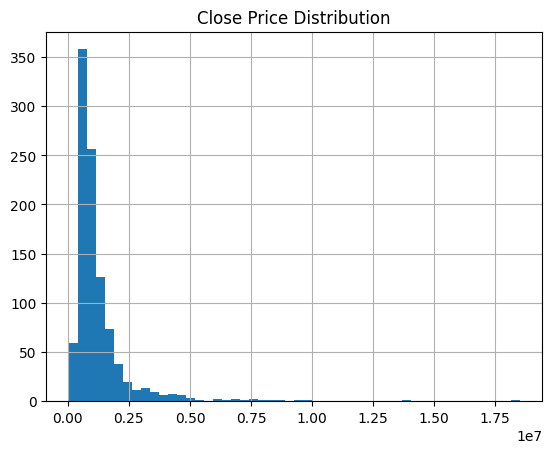

In [16]:
sold['ClosePrice'].hist(bins=50)
plt.title("Close Price Distribution")
plt.show()

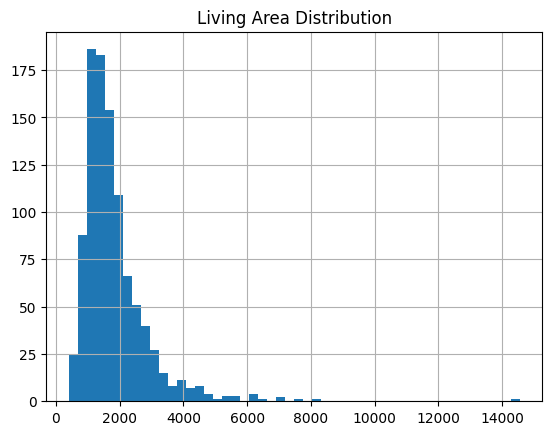

In [17]:
sold['LivingArea'].hist(bins=50)
plt.title("Living Area Distribution")
plt.show()

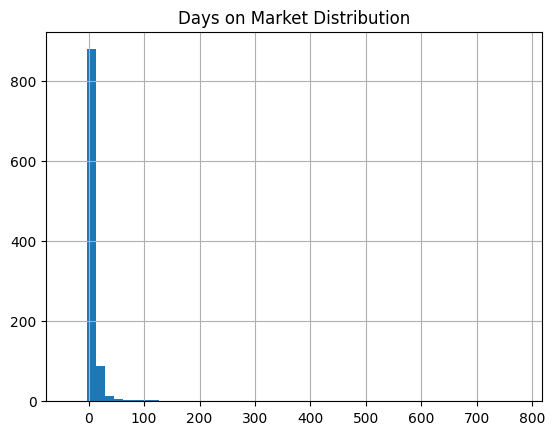

In [19]:
sold['DaysOnMarket'].hist(bins=50)
plt.title("Days on Market Distribution")
plt.show()

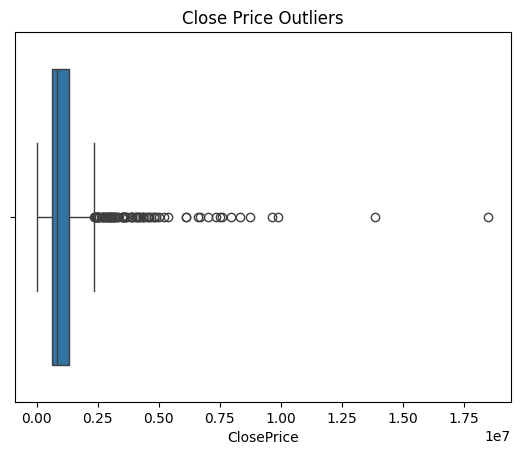

In [20]:
sns.boxplot(x=sold['ClosePrice'])
plt.title("Close Price Outliers")
plt.show()

In [21]:
# Mean VS Median Price
print("Mean:", sold['ClosePrice'].mean())
print("Median:", sold['ClosePrice'].median())

Mean: 1219142.738
Median: 853000.0


In [22]:
#Days on Market
sold['DaysOnMarket'].describe()

count    1000.000000
mean        7.931000
std        28.973396
min       -36.000000
25%         0.000000
50%         5.000000
75%         8.000000
max       777.000000
Name: DaysOnMarket, dtype: float64

In [24]:
#Sold Above vs Below List
sold['price_ratio'] = sold['ClosePrice'] / sold['ListPrice']

above = (sold['price_ratio'] > 1).mean()
below = (sold['price_ratio'] < 1).mean()

print("Above list:", above)
print("Below list:", below)

Above list: 0.506
Below list: 0.223


In [25]:
#Median Price by County
sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(10)

CountyOrParish
San Mateo        1812500.0
Santa Clara      1595000.0
Mendocino        1276500.0
Alameda          1084000.0
Orange           1050000.0
Monterey          985000.0
Los Angeles       929000.0
Santa Cruz        882500.0
Ventura           880000.0
San Francisco     875000.0
Name: ClosePrice, dtype: float64

In [26]:
# Data Validation
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])

invalid_dates = (sold['CloseDate'] < sold['ListingContractDate']).sum()
invalid_dates

np.int64(3)

In [27]:
#Mortgage Rate Enrichment
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

In [28]:
# Monthly aggregation
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

In [33]:
# Merge
sold['year_month'] = sold['CloseDate'].dt.to_period('M')

sold_enriched = sold.merge(mortgage_monthly, on='year_month', how='left')

In [34]:
# Validate
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

sold_enriched['rate_30yr_fixed'].isnull().sum()

np.int64(0)

In [35]:
# Save output
sold_enriched.to_csv("../output/sold_enriched_sample.csv", index=False)